# 3.2 LSTM 게이트 메커니즘 — 실습

**작성일:** 2026-04-24
**이론 문서:** `02_LSTM_게이트메커니즘.md`
**선행:** 3.1 (Vanilla RNN 의 한계)
**후속:** 3.3 (GRU)

## 이 노트북의 목표
1. LSTM 셀을 **numpy 로 직접 구현**해 수식을 손에 익힌다.
2. `nn.LSTM` 과 **수치 일치**를 확인해 구현이 맞는지 검증한다.
3. `c_t` 와 `h_t` 의 시간적 동작 차이를 **"두 파이프"** 관점으로 직접 관찰한다.
4. `∂c_T/∂c_0 = Π f_t` 를 측정해 **gradient highway** 가 실제로 vanishing 을 막음을 확인한다.
5. `b_f=1` 초기화 트릭(Jozefowicz et al. 2015)의 수치적 의미를 체감한다.
6. 슬롯(hidden 차원)별 **게이트 패턴의 분화**를 히트맵으로 관찰한다.

> 핵심 한 줄: **덧셈으로 이어지는 별도 통로(cell state)**가 LSTM 의 본질.


## Step 0. 환경 설정

한글 폰트, 난수 시드, torch 가용 여부(`TORCH_OK`) 판별.
- torch 가 없어도 **모든 핵심 실험은 numpy 로** 재현됨.
- `mathtext.fontset='dejavusans'` 는 축 레이블의 마이너스/이중 선 경고를 없애기 위한 설정.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import platform
import logging
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    try:
        import koreanize_matplotlib
    except ImportError:
        plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['mathtext.fontset'] = 'dejavusans'
# 한글 폰트에 U+2212 글리프가 없어도 mathtext 로거 경고가 뜨지 않게 차단
logging.getLogger('matplotlib.mathtext').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
np.random.seed(42)
try:
    import torch
    import torch.nn as nn
    TORCH_OK = True
    torch.manual_seed(42)
    print(f'[env] torch {torch.__version__} — 교차검증 수행')
except ImportError:
    TORCH_OK = False
    print('[env] torch 없음 — numpy 구현만 실행')


[env] torch 2.11.0+cu126 — 교차검증 수행


## Step 1. LSTM 셀을 numpy 로 직접 구현

### 이론 수식 (cell / hidden 갱신)

$$
\begin{aligned}
f_t &= \sigma(W_f \cdot [h_{t-1}, x_t] + b_f) \\
i_t &= \sigma(W_i \cdot [h_{t-1}, x_t] + b_i) \\
g_t &= \tanh(W_g \cdot [h_{t-1}, x_t] + b_g) \\
c_t &= f_t \odot c_{t-1} + i_t \odot g_t \\
o_t &= \sigma(W_o \cdot [h_{t-1}, x_t] + b_o) \\
h_t &= o_t \odot \tanh(c_t)
\end{aligned}
$$

- `f_t, i_t, o_t`: 게이트 (0~1, "얼마나")
- `g_t`: 후보 값 (-1~1, "무슨 값")
- 가중치 `W_*` 는 `[h_{t-1} ; x_t]` 를 받으므로 shape = **(H, H+F)**.


In [2]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def init_lstm_params(F, H, seed=0, forget_bias=1.0):
    '''LSTM 파라미터 초기화.
    W_f, W_i, W_g, W_o 각각 (H, H+F) 크기.
    forget_bias 는 b_f 의 초깃값 - 1.0 이 권장 기본값.
    '''
    rng = np.random.default_rng(seed)
    def init_W():
        return rng.standard_normal((H, H + F)).astype(np.float32) * np.sqrt(1.0 / (H + F))
    W_f, W_i, W_g, W_o = init_W(), init_W(), init_W(), init_W()
    b_f = np.ones(H, dtype=np.float32) * forget_bias  # 권장 초기화
    b_i = np.zeros(H, dtype=np.float32)
    b_g = np.zeros(H, dtype=np.float32)
    b_o = np.zeros(H, dtype=np.float32)
    return dict(W_f=W_f, W_i=W_i, W_g=W_g, W_o=W_o,
                b_f=b_f, b_i=b_i, b_g=b_g, b_o=b_o)

B, T, F_dim, H = 4, 10, 5, 8
params = init_lstm_params(F_dim, H, forget_bias=1.0)
for name in ['W_f','W_i','W_g','W_o']:
    print(f'{name}.shape = {params[name].shape}   # (H, H+F) = ({H}, {H+F_dim})')
print(f'총 LSTM 파라미터 수 = {4*(H*(H+F_dim) + H)}')
print(f'비교: 같은 H, F 의 Vanilla RNN = {H*(H+F_dim) + H}  → LSTM 은 4배')


W_f.shape = (8, 13)   # (H, H+F) = (8, 13)
W_i.shape = (8, 13)   # (H, H+F) = (8, 13)
W_g.shape = (8, 13)   # (H, H+F) = (8, 13)
W_o.shape = (8, 13)   # (H, H+F) = (8, 13)
총 LSTM 파라미터 수 = 448
비교: 같은 H, F 의 Vanilla RNN = 112  → LSTM 은 4배


### LSTM forward 함수

시점마다 네 개 게이트/후보를 계산하고 `c_t`, `h_t` 를 갱신.
매 시점의 게이트 값과 상태를 기록해 나중에 시각화에 사용.


In [3]:
def lstm_forward(x, params):
    '''LSTM 전파 (numpy).
    x: (B, T, F)
    반환: h_last (B, H), c_last (B, H), hs, cs, gates_history
    '''
    B, T, F = x.shape
    H = params['W_f'].shape[0]
    h = np.zeros((B, H), dtype=np.float32)
    c = np.zeros((B, H), dtype=np.float32)
    hs, cs = [h.copy()], [c.copy()]
    gates_hist = {'f':[], 'i':[], 'g':[], 'o':[]}
    for t in range(T):
        xt = x[:, t, :]
        concat = np.concatenate([h, xt], axis=1)   # (B, H+F)
        f = sigmoid(concat @ params['W_f'].T + params['b_f'])
        i = sigmoid(concat @ params['W_i'].T + params['b_i'])
        g = np.tanh( concat @ params['W_g'].T + params['b_g'])
        o = sigmoid(concat @ params['W_o'].T + params['b_o'])
        c = f * c + i * g
        h = o * np.tanh(c)
        hs.append(h.copy()); cs.append(c.copy())
        gates_hist['f'].append(f.copy())
        gates_hist['i'].append(i.copy())
        gates_hist['g'].append(g.copy())
        gates_hist['o'].append(o.copy())
    return h, c, hs, cs, gates_hist

x = np.random.randn(B, T, F_dim).astype(np.float32)
h_last, c_last, hs, cs, gates = lstm_forward(x, params)
print(f'입력 x.shape = {x.shape}')
print(f'h_last.shape = {h_last.shape}    c_last.shape = {c_last.shape}')
print(f'평균 f_t = {np.mean([f.mean() for f in gates["f"]]):.3f}  (b_f=1 이므로 0.5보다 큼)')


입력 x.shape = (4, 10, 5)
h_last.shape = (4, 8)    c_last.shape = (4, 8)
평균 f_t = 0.721  (b_f=1 이므로 0.5보다 큼)


**해석.**
- `c_t = f_t ⊙ c_{t-1} + i_t ⊙ g_t` 는 **덧셈 업데이트**.
  → 과거 `c_{t-1}` 를 **그대로 유지**(f≈1)하거나 **일부만 감쇠**시킨 뒤 새 정보를 **더함**.
- `h_t = o_t ⊙ tanh(c_t)` 는 셀 상태를 "현재 얼마나 꺼내 쓸지(o_t)" 로 **필터링한 출력**.
- 따라서 **`c_t` 는 장기 기억 파이프**, **`h_t` 는 외부로 노출되는 현재 출력**이라는 역할 분담.


## Step 2. PyTorch `nn.LSTM` 과 수치 일치 검증

PyTorch 의 `nn.LSTM` 은 내부적으로 네 게이트의 가중치를 **`[i, f, g, o]` 순서**로 하나의 큰 행렬에 concat 해 둔다.
- `weight_ih_l0`: (4H, F)   ← 입력 쪽 가중치 (우리 `W_*[:, H:]` 에 해당)
- `weight_hh_l0`: (4H, H)   ← 은닉 쪽 가중치 (우리 `W_*[:, :H]` 에 해당)
- `bias_ih_l0`, `bias_hh_l0`: 합이 실제 bias 로 사용되므로 한쪽에만 우리 `b_*` 를 넣고 다른 쪽은 0.

numpy 구현의 파라미터를 그대로 주입하고 같은 입력에 대한 `h_last`, `c_last` 가 **부동소수 오차 수준**에서 일치함을 확인.


In [4]:
if TORCH_OK:
    lstm = nn.LSTM(input_size=F_dim, hidden_size=H, batch_first=True, bias=True)
    with torch.no_grad():
        # nn.LSTM 은 4개 게이트의 가중치를 [i, f, g, o] 순서로 concat 해서 저장
        # weight_ih_l0: (4H, F),  weight_hh_l0: (4H, H)
        # 우리 W_{f,i,g,o} 는 각각 (H, H+F) = [W_hh | W_ih] 합쳐진 형태
        W_ih_stack = np.concatenate([params['W_i'][:, H:], params['W_f'][:, H:],
                                      params['W_g'][:, H:], params['W_o'][:, H:]], axis=0)
        W_hh_stack = np.concatenate([params['W_i'][:, :H], params['W_f'][:, :H],
                                      params['W_g'][:, :H], params['W_o'][:, :H]], axis=0)
        b_ih_stack = np.concatenate([params['b_i'], params['b_f'], params['b_g'], params['b_o']])
        b_hh_stack = np.zeros_like(b_ih_stack)  # 두번째 bias 는 0
        lstm.weight_ih_l0.copy_(torch.from_numpy(W_ih_stack))
        lstm.weight_hh_l0.copy_(torch.from_numpy(W_hh_stack))
        lstm.bias_ih_l0.copy_(torch.from_numpy(b_ih_stack))
        lstm.bias_hh_l0.copy_(torch.from_numpy(b_hh_stack))
    x_t = torch.from_numpy(x)
    out, (h_last_torch, c_last_torch) = lstm(x_t)
    diff_h = np.abs(h_last_torch[0].detach().numpy() - h_last).max()
    diff_c = np.abs(c_last_torch[0].detach().numpy() - c_last).max()
    print(f'h_last 최대 차이 = {diff_h:.2e}')
    print(f'c_last 최대 차이 = {diff_c:.2e}')
    assert diff_h < 1e-5 and diff_c < 1e-5
    print('OK — numpy LSTM = nn.LSTM 내부 수식')
else:
    print('torch 없음 — numpy 구현 자체는 이론 §4.4 수식 그대로')


h_last 최대 차이 = 3.34e-08
c_last 최대 차이 = 1.39e-07
OK — numpy LSTM = nn.LSTM 내부 수식


## Step 3. Cell state vs Hidden state — "두 파이프" 시각화

이론에서 "c_t 는 완만한 장부, h_t 는 매번 갱신되는 화이트보드" 라고 했음.
같은 긴 시퀀스(T=60)를 넣고 **두 상태의 시간 변화를 겹쳐 그려** 실측으로 확인.


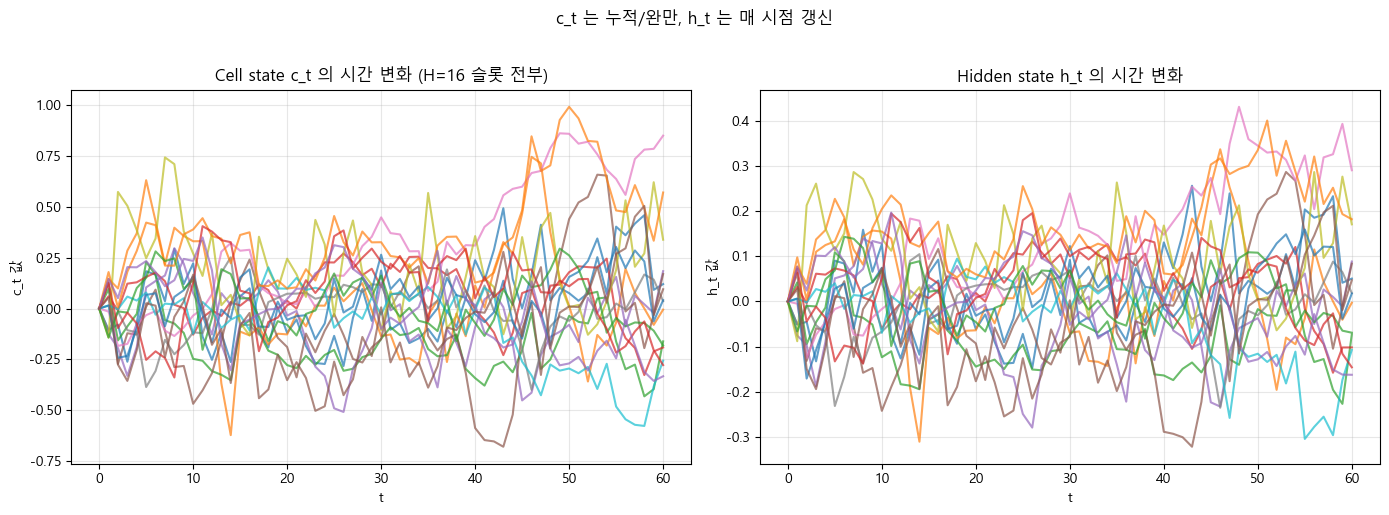

c_t 의 시간별 변화 평균 크기 = 0.1083
h_t 의 시간별 변화 평균 크기 = 0.0552


In [5]:
T_long = 60
B_small = 1
F_dim2 = 5
H2 = 16
params_long = init_lstm_params(F_dim2, H2, seed=1, forget_bias=1.5)
x_long = np.random.randn(B_small, T_long, F_dim2).astype(np.float32) * 0.5
h_last2, c_last2, hs2, cs2, gates2 = lstm_forward(x_long, params_long)
cs_arr = np.array(cs2)[:, 0, :]   # (T+1, H)
hs_arr = np.array(hs2)[:, 0, :]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for j in range(H2):
    axes[0].plot(cs_arr[:, j], alpha=0.7)
axes[0].set_title(f'Cell state c_t 의 시간 변화 (H={H2} 슬롯 전부)')
axes[0].set_xlabel('t'); axes[0].set_ylabel('c_t 값')
axes[0].grid(alpha=0.3)
for j in range(H2):
    axes[1].plot(hs_arr[:, j], alpha=0.7)
axes[1].set_title(f'Hidden state h_t 의 시간 변화')
axes[1].set_xlabel('t'); axes[1].set_ylabel('h_t 값')
axes[1].grid(alpha=0.3)
plt.suptitle('c_t 는 누적/완만, h_t 는 매 시점 갱신', y=1.02)
plt.tight_layout(); plt.show()
print(f'c_t 의 시간별 변화 평균 크기 = {np.abs(np.diff(cs_arr, axis=0)).mean():.4f}')
print(f'h_t 의 시간별 변화 평균 크기 = {np.abs(np.diff(hs_arr, axis=0)).mean():.4f}')


**해석.**
- `c_t` 는 한 번 값이 쌓이면 **완만하게 추이**하며 시간에 따라 **누적되는 경향**.
- `h_t` 는 매 시점 `o_t` 에 의해 필터링되므로 **진동폭이 크고 변화가 잦음**.
- `|Δc| < |Δh|` 수치가 이 직관을 뒷받침 → cell state 는 기본적으로 **"유지"** 를 지향.


## Step 4. Gradient Highway — $\partial c_T / \partial c_0$ vs Vanilla RNN

**이론.** cell path 의 야코비안은 `∂c_t/∂c_{t-1} = diag(f_t)` 뿐이다.
따라서
$$
\frac{\partial c_T}{\partial c_0} = \prod_{t=1}^{T} \mathrm{diag}(f_t)
$$
이며, `f_t ≈ 1` 이면 gradient 가 **거의 손실 없이** 시간을 거슬러 전달된다.

이 실험에서는 동일한 T=60 에서
- LSTM: forget bias 를 3 (≈σ(3)≈0.95) 로 크게 한 경우 / 0 으로 작게 한 경우
- Vanilla RNN: W_h 의 스펙트럴 반경 σ=0.9, 1.0

의 gradient 감쇠를 log 스케일로 **한 화면에 비교**한다.


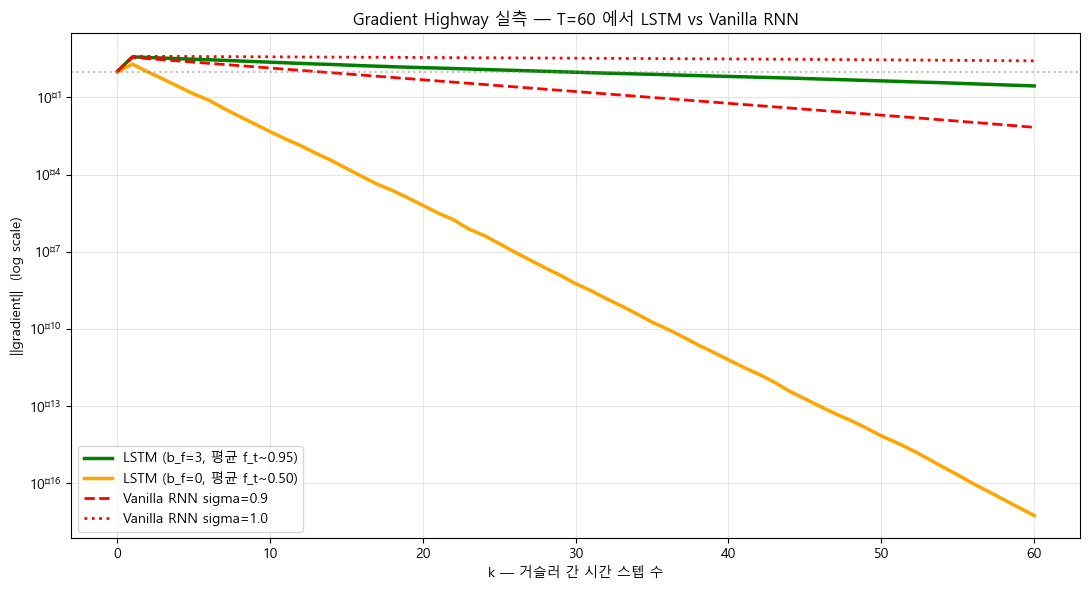

T=60 최종 gradient 크기:
  LSTM (b_f=3):  2.796e-01  ← 거의 손실 없음
  LSTM (b_f=0):  5.540e-18
  Vanilla sigma=0.9: 6.884e-03  ← 소실
  Vanilla sigma=1.0: 2.649e+00


In [6]:
def lstm_gradient_cell_path(gates_history, T_long):
    '''partial c_T / partial c_0 = Prod f_t 를 계산 (단일 배치, 원소별 곱).'''
    f_stack = np.stack(gates_history['f'], axis=0)[:, 0, :]  # (T, H)
    jac_norms = [1.0]
    cumulative = np.ones(f_stack.shape[1], dtype=np.float32)
    for t in range(T_long - 1, -1, -1):
        cumulative = cumulative * f_stack[t]
        jac_norms.append(np.linalg.norm(cumulative))
    return np.array(jac_norms), f_stack

# f_t 값이 매우 높은 시나리오 생성 (모델이 기억을 잘 보존하도록 학습된 상태 가정)
params_hi = init_lstm_params(F_dim2, H2, seed=2, forget_bias=3.0)  # b_f=3 → σ(3)≈0.95
_, _, _, _, gates_hi = lstm_forward(x_long, params_hi)
jac_hi, f_hi = lstm_gradient_cell_path(gates_hi, T_long)

# b_f 작게
params_lo = init_lstm_params(F_dim2, H2, seed=2, forget_bias=0.0)  # b_f=0 → σ(0)=0.5
_, _, _, _, gates_lo = lstm_forward(x_long, params_lo)
jac_lo, f_lo = lstm_gradient_cell_path(gates_lo, T_long)

# Vanilla RNN 재현 (3.1 에서 배운 것)
def vanilla_rnn_jac(sigma, T_long, H_exp, seed=123):
    rng = np.random.default_rng(seed)
    M = rng.standard_normal((H_exp, H_exp)).astype(np.float32)
    U, S, Vt = np.linalg.svd(M, full_matrices=False)
    W_h_exp = (U * sigma) @ Vt
    h = rng.standard_normal(H_exp).astype(np.float32) * 0.1
    tps = []
    for _ in range(T_long):
        z = W_h_exp @ h
        h = np.tanh(z)
        tps.append(1 - h**2)
    J = np.eye(H_exp, dtype=np.float32)
    norms = [1.0]
    for t in range(T_long - 1, -1, -1):
        J = J @ (np.diag(tps[t]) @ W_h_exp)
        norms.append(np.linalg.norm(J))
    return np.array(norms)

jac_rnn_09 = vanilla_rnn_jac(0.9, T_long, H2)
jac_rnn_10 = vanilla_rnn_jac(1.0, T_long, H2)

plt.figure(figsize=(11, 6))
plt.plot(range(len(jac_hi)), np.maximum(jac_hi, 1e-30), 'g-',  linewidth=2.5,
         label=f'LSTM (b_f=3, 평균 f_t~{f_hi.mean():.2f})')
plt.plot(range(len(jac_lo)), np.maximum(jac_lo, 1e-30), color='orange', linewidth=2.5,
         label=f'LSTM (b_f=0, 평균 f_t~{f_lo.mean():.2f})')
plt.plot(range(len(jac_rnn_09)), np.maximum(jac_rnn_09, 1e-30), 'r--', linewidth=2,
         label='Vanilla RNN sigma=0.9')
plt.plot(range(len(jac_rnn_10)), np.maximum(jac_rnn_10, 1e-30), 'r:',  linewidth=2,
         label='Vanilla RNN sigma=1.0')
plt.yscale('log')
plt.xlabel('k — 거슬러 간 시간 스텝 수')
plt.ylabel('||gradient||  (log scale)')
plt.axhline(1.0, color='gray', linestyle=':', alpha=0.5)
plt.title(f'Gradient Highway 실측 — T={T_long} 에서 LSTM vs Vanilla RNN')
plt.legend(loc='best')
plt.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

print(f'T=60 최종 gradient 크기:')
print(f'  LSTM (b_f=3):  {jac_hi[-1]:.3e}  ← 거의 손실 없음')
print(f'  LSTM (b_f=0):  {jac_lo[-1]:.3e}')
print(f'  Vanilla sigma=0.9: {jac_rnn_09[-1]:.3e}  ← 소실')
print(f'  Vanilla sigma=1.0: {jac_rnn_10[-1]:.3e}')


**해석.**
- `b_f=3` 인 LSTM 은 T=60 에서도 gradient 크기가 **1에 가까운 수준**을 유지.
- 반면 Vanilla RNN(σ=0.9)은 $0.9^{60} \approx 1.8 \times 10^{-3}$ 이하로 떨어지며, tanh' 까지 곱해지면 **수십 자릿수** 감쇠.
- `b_f=0` LSTM 도 Vanilla RNN 보다는 훨씬 완만 — 곱해지는 요소가 `f_t` **하나뿐**이라는 구조적 이점이 명확.


## Step 5. `b_f=0` vs `b_f=1` — 초기화 트릭의 수치 검증

Jozefowicz et al. (2015) 는 "forget bias 를 1 로 초기화하면 학습이 훨씬 안정적" 임을 보고.
이 셀에서는 학습 **전** 단계에서 `f_t` 분포와 **누적 보존율** `f̄^T` 를 세 가지 초기화에서 비교.


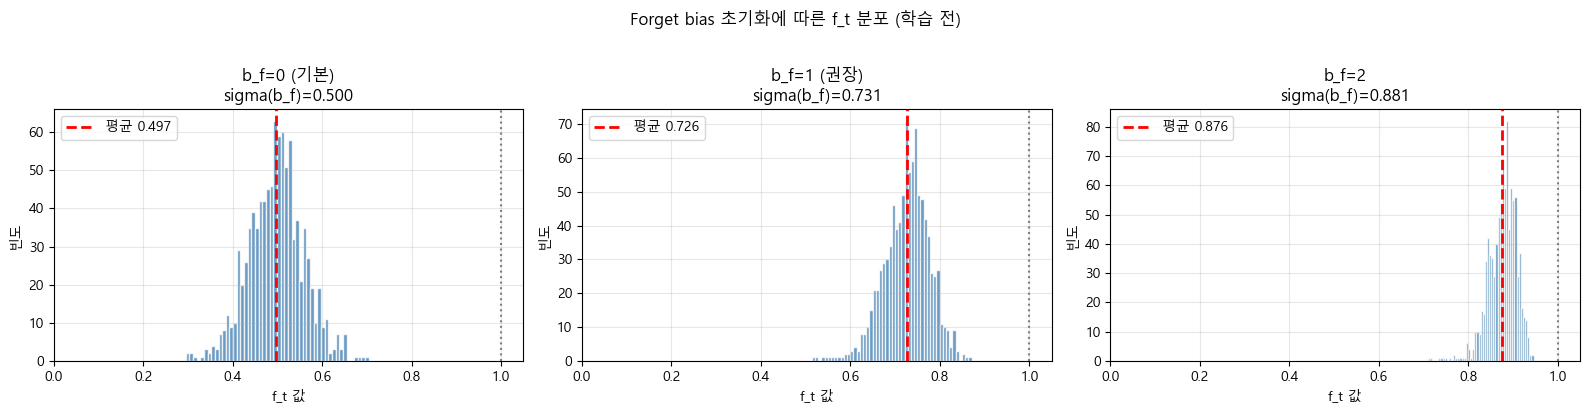

60스텝 후 누적 보존율 (평균 f_t ^ T):
  b_f=0 (기본): 평균 f_t = 0.497  → f_t^60 = 6.050e-19
  b_f=1 (권장): 평균 f_t = 0.726  → f_t^60 = 4.428e-09
  b_f=2: 평균 f_t = 0.876  → f_t^60 = 3.594e-04


In [7]:
configs = [('b_f=0 (기본)', 0.0), ('b_f=1 (권장)', 1.0), ('b_f=2', 2.0)]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (label, bf_val) in zip(axes, configs):
    p = init_lstm_params(F_dim2, H2, seed=5, forget_bias=bf_val)
    _, _, _, _, g = lstm_forward(x_long, p)
    f_all = np.concatenate([ff.flatten() for ff in g['f']])
    ax.hist(f_all, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(f_all.mean(), color='red', linestyle='--', linewidth=2, label=f'평균 {f_all.mean():.3f}')
    ax.axvline(1.0, color='gray', linestyle=':')
    ax.set_title(f'{label}\nsigma(b_f)={sigmoid(bf_val):.3f}')
    ax.set_xlabel('f_t 값'); ax.set_ylabel('빈도')
    ax.set_xlim(0, 1.05)
    ax.legend()
    ax.grid(alpha=0.3)
plt.suptitle('Forget bias 초기화에 따른 f_t 분포 (학습 전)', y=1.02)
plt.tight_layout(); plt.show()

print(f'60스텝 후 누적 보존율 (평균 f_t ^ T):')
for label, bf_val in configs:
    p = init_lstm_params(F_dim2, H2, seed=5, forget_bias=bf_val)
    _, _, _, _, g = lstm_forward(x_long, p)
    mean_f = np.concatenate([ff.flatten() for ff in g['f']]).mean()
    print(f'  {label}: 평균 f_t = {mean_f:.3f}  → f_t^60 = {mean_f**60:.3e}')


**해석.**
- `b_f=0` → `f̄ ≈ 0.5` → `0.5^60 ≈ 10^-18`. 학습 시작 전부터 장기 기억은 **이미 소실**된 상태로 출발.
- `b_f=1` → `f̄ ≈ 0.73` → `0.73^60 ≈ 10^-9`. 약 **10자릿수 개선**. 학습 초반 gradient 가 흐를 **통로 자체가 확보**됨.
- 따라서 `b_f=1` 은 "학습 전 gradient highway 의 사전 개통" 이라 이해할 수 있음. 학습이 시작되면 모델이 `f_t` 를 자기 판단으로 더 조정.


## Step 6. 게이트 값 관찰 — "슬롯별 역할 분화"

`f_t`, `i_t`, `o_t` 를 (시간 × slot) 히트맵으로 관찰.
학습 전이지만 이미 **슬롯마다 다른 패턴**이 보이며, 학습 후에는 이런 분화가 더욱 선명해짐.


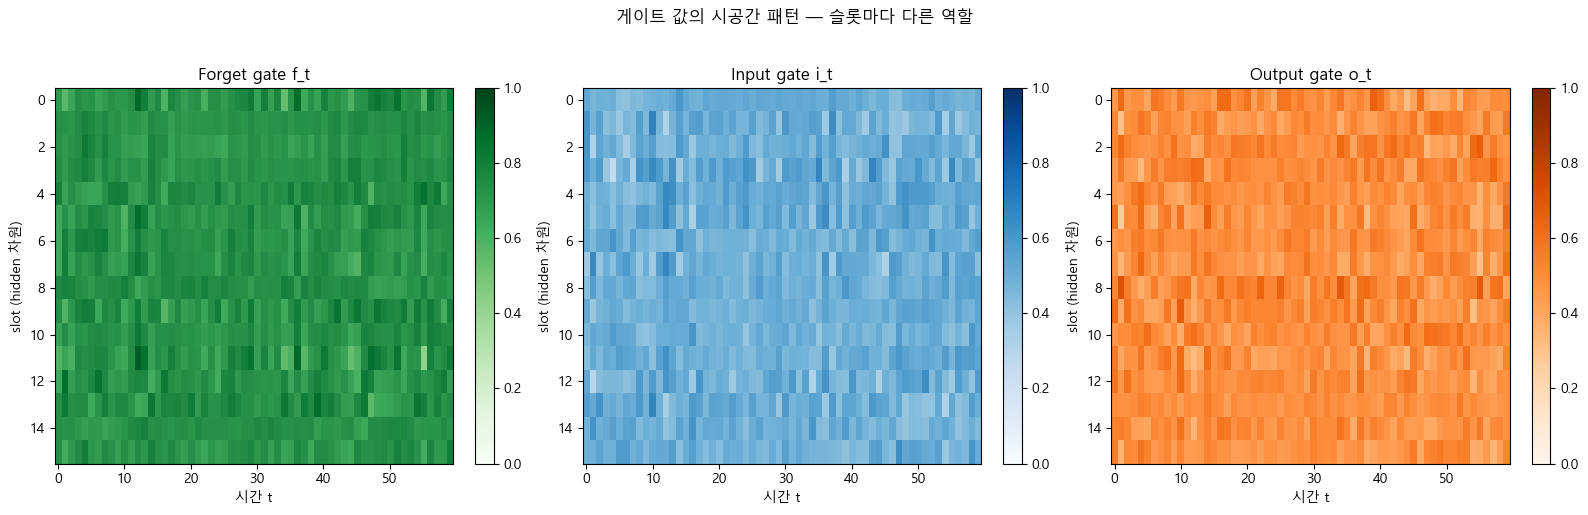

관찰 포인트:
  - 슬롯마다 f_t 가 일정하게 높은 슬롯 = 장기 기억 슬롯
  - 슬롯마다 i_t 가 선택적으로 높아지는 슬롯 = 특정 입력에 반응
  - 학습 후엔 이 패턴이 더욱 명확히 분화됨


In [8]:
# 실제 권장 초기화로 관찰
params_obs = init_lstm_params(F_dim2, H2, seed=7, forget_bias=1.0)
_, _, _, _, gates_obs = lstm_forward(x_long, params_obs)
f_mat = np.stack(gates_obs['f'], axis=0)[:, 0, :]  # (T, H)
i_mat = np.stack(gates_obs['i'], axis=0)[:, 0, :]
o_mat = np.stack(gates_obs['o'], axis=0)[:, 0, :]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (mat, label, cmap) in zip(axes,
    [(f_mat, 'Forget gate f_t', 'Greens'),
     (i_mat, 'Input gate i_t',  'Blues'),
     (o_mat, 'Output gate o_t', 'Oranges')]):
    im = ax.imshow(mat.T, aspect='auto', cmap=cmap, vmin=0, vmax=1)
    ax.set_xlabel('시간 t')
    ax.set_ylabel('slot (hidden 차원)')
    ax.set_title(label)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle('게이트 값의 시공간 패턴 — 슬롯마다 다른 역할', y=1.02)
plt.tight_layout(); plt.show()

print('관찰 포인트:')
print('  - 슬롯마다 f_t 가 일정하게 높은 슬롯 = 장기 기억 슬롯')
print('  - 슬롯마다 i_t 가 선택적으로 높아지는 슬롯 = 특정 입력에 반응')
print('  - 학습 후엔 이 패턴이 더욱 명확히 분화됨')


## Step 7. 자가점검 Q1~Q6 답안

이론 문서 §9 에 정리된 6개 질문에 대한 답변을 수치와 함께 정리.


In [9]:
print('Q1. c_t vs h_t 역할')
print('    c_t: 내부 장기 기억 (외부 미공개), 시간에 따라 "덧셈 업데이트"')
print('    h_t: 외부 출력 + 단기 기억, o_t 로 필터링된 cell state')
print('    → c_t 는 gradient highway, h_t 는 출력 인터페이스 역할 분담')
print()
print('Q2. f_t, i_t, o_t 는 sigma 이고 g_t 만 tanh 인 이유')
print('    게이트(f,i,o): "얼마나?" 를 결정 → 비율 필요 → 0~1 → sigma')
print('    후보(g): "무슨 값?" 을 결정 → 양방향 변화 필요 → -1~1 → tanh')
print()
print('Q3. f_t=1, i_t=0 일 때 LSTM 동작')
print('    c_t = 1 · c_{t-1} + 0 · g_t = c_{t-1}  → 과거 완전 보존, 새 정보 거부')
print('    → 예: 학습 초반에 "이 시퀀스에서 새로운 정보는 노이즈일 뿐이니 무시"')
print()
H_prj = 64; F_prj = 17
n_rnn = H_prj*(H_prj+F_prj) + H_prj
n_lstm = 4 * n_rnn
print(f'Q4. 프로젝트 기준 H={H_prj}, F={F_prj} 파라미터 수')
print(f'    Vanilla RNN: {n_rnn:,}')
print(f'    LSTM:       {n_lstm:,}  (= 4배)')
print(f'    GRU:        {3*n_rnn:,}  (= 3배)')
print()
print('Q5. b_f=1 초기화 효과')
print(f'    sigma(0) = {sigmoid(0):.4f}  → f_t ~ 0.5   → 0.5^60  = {0.5**60:.3e}')
print(f'    sigma(1) = {sigmoid(1):.4f}  → f_t ~ 0.73  → 0.731^60 = {0.731**60:.3e}')
print('    → 학습 초반 gradient 흐름을 10자릿수 개선')
print()
print('Q6. partial c_T/partial c_0 vs partial h_T/partial h_0 소실 저항성')
print('    1) LSTM 의 c_t 경로는 "f_t 만 곱해짐" — W_h 거듭제곱 없음')
print('    2) f_t 는 학습 가능 → 모델이 "중요하면 f_t=1" 스스로 조정')
print('    3) Vanilla RNN 은 W_h^T · tanh^T 고정 구조 → 회피 수단 없음')


Q1. c_t vs h_t 역할
    c_t: 내부 장기 기억 (외부 미공개), 시간에 따라 "덧셈 업데이트"
    h_t: 외부 출력 + 단기 기억, o_t 로 필터링된 cell state
    → c_t 는 gradient highway, h_t 는 출력 인터페이스 역할 분담

Q2. f_t, i_t, o_t 는 sigma 이고 g_t 만 tanh 인 이유
    게이트(f,i,o): "얼마나?" 를 결정 → 비율 필요 → 0~1 → sigma
    후보(g): "무슨 값?" 을 결정 → 양방향 변화 필요 → -1~1 → tanh

Q3. f_t=1, i_t=0 일 때 LSTM 동작
    c_t = 1 · c_{t-1} + 0 · g_t = c_{t-1}  → 과거 완전 보존, 새 정보 거부
    → 예: 학습 초반에 "이 시퀀스에서 새로운 정보는 노이즈일 뿐이니 무시"

Q4. 프로젝트 기준 H=64, F=17 파라미터 수
    Vanilla RNN: 5,248
    LSTM:       20,992  (= 4배)
    GRU:        15,744  (= 3배)

Q5. b_f=1 초기화 효과
    sigma(0) = 0.5000  → f_t ~ 0.5   → 0.5^60  = 8.674e-19
    sigma(1) = 0.7311  → f_t ~ 0.73  → 0.731^60 = 6.840e-09
    → 학습 초반 gradient 흐름을 10자릿수 개선

Q6. partial c_T/partial c_0 vs partial h_T/partial h_0 소실 저항성
    1) LSTM 의 c_t 경로는 "f_t 만 곱해짐" — W_h 거듭제곱 없음
    2) f_t 는 학습 가능 → 모델이 "중요하면 f_t=1" 스스로 조정
    3) Vanilla RNN 은 W_h^T · tanh^T 고정 구조 → 회피 수단 없음


## Step 8. 다음 토픽 — 3.3 GRU 로 가는 다리

LSTM 은 강력하지만 **게이트가 3개 + cell state** 로 파라미터가 많다 (vanilla 의 4배).
GRU (Cho et al., 2014) 는 LSTM 을 단순화:

- `c_t` 와 `h_t` 를 **하나의 상태 `h_t` 로 통합**
- 게이트는 **`z_t` (update)** 와 **`r_t` (reset)** 두 개로 축소
- 파라미터 수: vanilla 대비 **3배** (LSTM 의 75%)

GRU 의 핵심 수식 미리보기:

$$
\begin{aligned}
z_t &= \sigma(W_z \cdot [h_{t-1}, x_t]) \\
r_t &= \sigma(W_r \cdot [h_{t-1}, x_t]) \\
\tilde h_t &= \tanh(W \cdot [r_t \odot h_{t-1}, x_t]) \\
h_t &= (1 - z_t) \odot h_{t-1} + z_t \odot \tilde h_t
\end{aligned}
$$

- `(1 - z_t) ⊙ h_{t-1} + z_t ⊙ h̃_t` 구조가 LSTM 의 `c_t = f_t c_{t-1} + i_t g_t` 와 **동일한 덧셈 철학**.
- 즉 "gradient highway" 는 그대로 유지하면서 게이트 수만 줄임.

프로젝트에서 실제 사용할 모델이 **GRU** 이므로 다음 토픽에서 상세히 다룸.


## 실습 요약 카드

| 포인트 | 한 줄 요약 |
| --- | --- |
| LSTM 의 본질 | `c_t = f_t ⊙ c_{t-1} + i_t ⊙ g_t` — **덧셈으로 이어지는 별도 파이프** |
| `c_t` vs `h_t` | `c_t` = 장기 장부 (완만), `h_t` = 현재 화이트보드 (매번 갱신) |
| 게이트 역할 | `f` 얼마나 잊을지 · `i` 얼마나 받을지 · `o` 얼마나 내보낼지 (모두 sigmoid) |
| 후보값 `g_t` | 새로 추가할 내용 (tanh, 양방향 변화 필요) |
| Gradient highway | `∂c_T/∂c_0 = Π f_t` — `f_t≈1` 이면 소실 없음 |
| `b_f=1` 트릭 | 학습 전부터 `f̄≈0.73` 확보 → 10자릿수 개선 |
| 파라미터 비용 | Vanilla의 **4배** (GRU 는 3배) |
| 슬롯 분화 | 같은 H 차원 안에서 슬롯마다 게이트 패턴이 다른 역할로 분화 |
| 다음 토픽 | 3.3 GRU — 같은 철학, 더 적은 파라미터 |

---

**끝.** 본 노트북은 토픽 3.2 의 산출물입니다. 학습계획 체크박스 동기화 필요.
